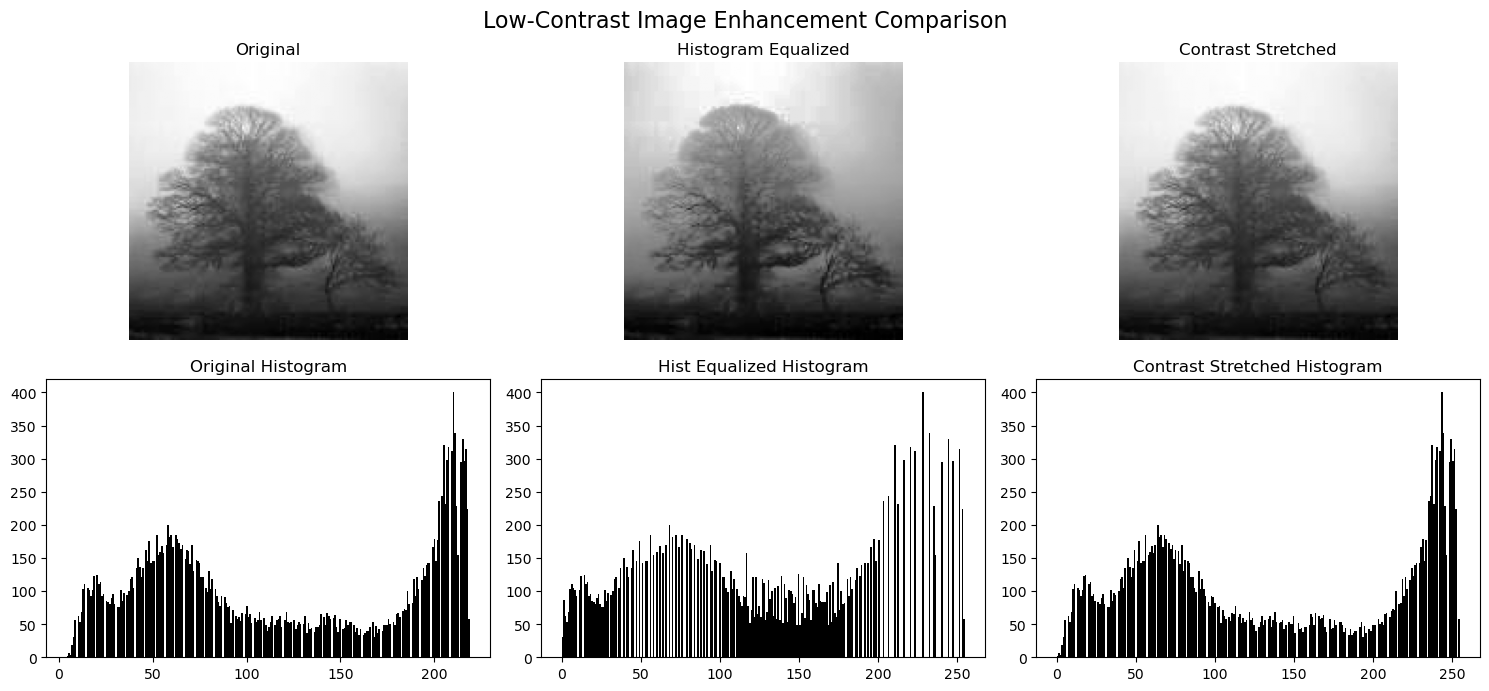

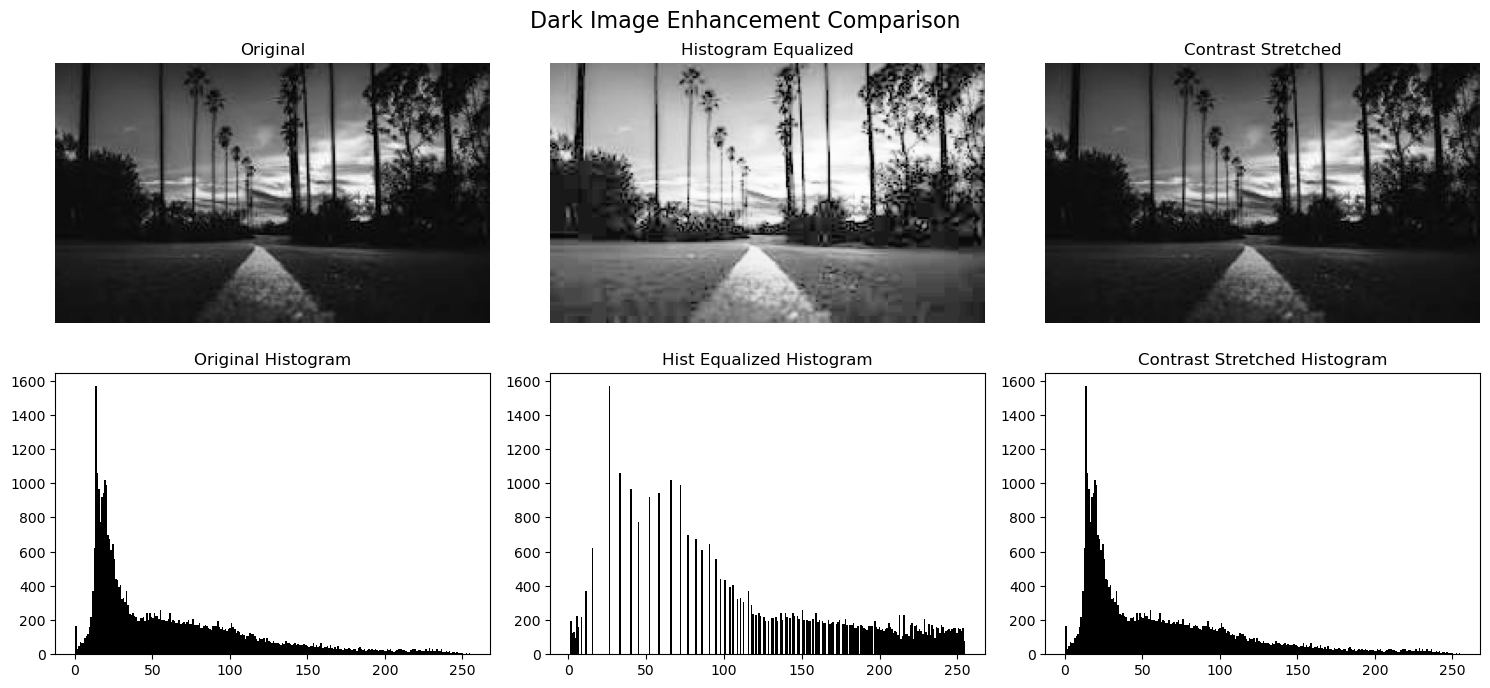

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images (grayscale)
img1 = cv2.imread("image1.jpeg", 0)  # low-contrast image
img2 = cv2.imread("image2.jpeg", 0)  # dark/underexposed image

def histogram_equalization_manual(img):
    # Compute histogram
    hist = np.zeros(256)
    for pixel in img.ravel():
        hist[pixel] += 1
    # Normalize histogram
    hist = hist / img.size
    # Compute cumulative distribution function (CDF)
    cdf = np.cumsum(hist)
    # Mapping
    mapping = np.round(cdf * 255).astype(np.uint8)
    # Apply mapping
    img_eq = mapping[img]
    return img_eq, hist, mapping

def contrast_stretching(img):
    r_min = np.min(img)
    r_max = np.max(img)
    # Apply formula: s = [(r - r_min)/(r_max - r_min)] * 255
    stretched = ((img - r_min) / (r_max - r_min) * 255).astype(np.uint8)
    return stretched

def plot_comparison(original, hist_eq, contrast, title):
    plt.figure(figsize=(15,10))

    # Images
    plt.subplot(3,3,1); plt.imshow(original, cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(3,3,2); plt.imshow(hist_eq, cmap='gray'); plt.title("Histogram Equalized"); plt.axis('off')
    plt.subplot(3,3,3); plt.imshow(contrast, cmap='gray'); plt.title("Contrast Stretched"); plt.axis('off')

    # Histograms
    plt.subplot(3,3,4); plt.hist(original.ravel(), bins=256, color='black'); plt.title("Original Histogram")
    plt.subplot(3,3,5); plt.hist(hist_eq.ravel(), bins=256, color='black'); plt.title("Hist Equalized Histogram")
    plt.subplot(3,3,6); plt.hist(contrast.ravel(), bins=256, color='black'); plt.title("Contrast Stretched Histogram")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Apply histogram equalization (manual)
eq1, hist1, map1 = histogram_equalization_manual(img1)
eq2, hist2, map2 = histogram_equalization_manual(img2)

# Apply contrast stretching
cs1 = contrast_stretching(img1)
cs2 = contrast_stretching(img2)

# Plot comparisons
plot_comparison(img1, eq1, cs1, "Low-Contrast Image Enhancement Comparison")
plot_comparison(img2, eq2, cs2, "Dark Image Enhancement Comparison")
